# Student Score Prediction 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,accuracy_score


Load the dataset

In [2]:
data = pd.read_csv(r"C:\Users\alibro\Desktop\student_performance_predictor\data\student_performance.csv")

X = data[['study_hours',
        'self_study_hours',
        'sleep_hours',
        'focus_index',
        'burnout_level',
        'productivity_score',
        'mental_health_score',
        'screen_time_hours',
        'social_media_hours',
        'gaming_hours'
    ]]

y = data['exam_score']

Explotary Data Analysis

In [3]:
data.head()
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   str    
 3   academic_level        5000 non-null   str    
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality      5000 non-n

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [4]:
data.isnull().sum()

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

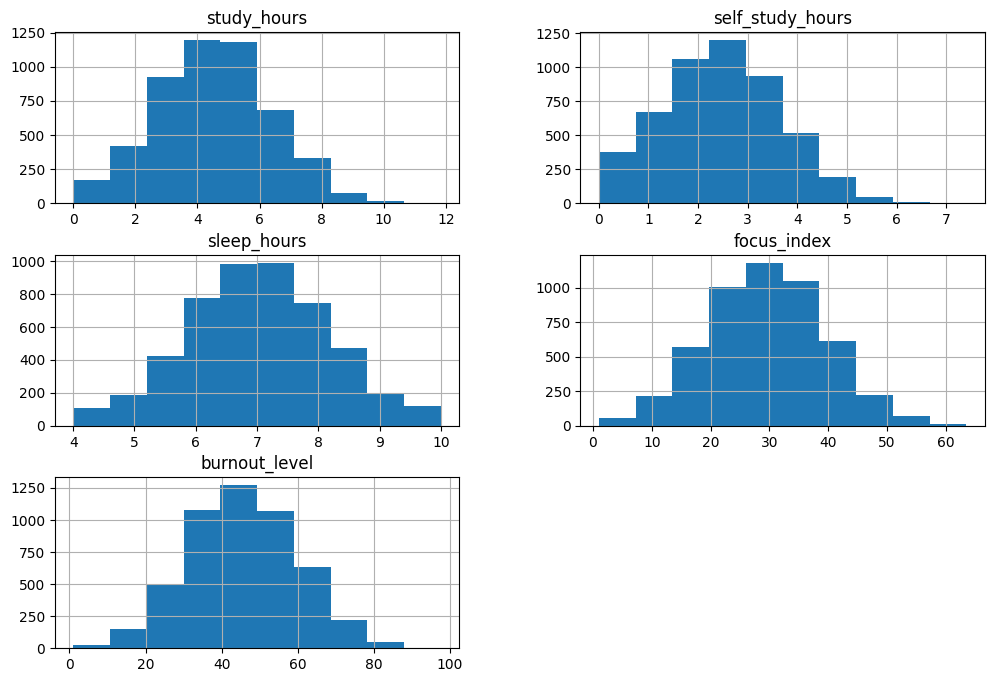

In [5]:
data[['study_hours', 'self_study_hours', 'sleep_hours', 'focus_index', 'burnout_level']].hist(figsize=(12,8))
plt.show()

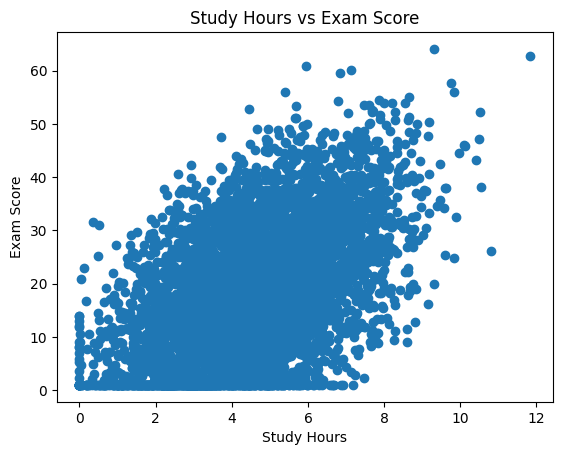

In [6]:
plt.scatter(data['study_hours'], data['exam_score'])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")
plt.show()

Train the Model

In [7]:
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=42,test_size=0.2)
model1 = LinearRegression()
model2 = RandomForestRegressor(n_estimators=200)
model3 = DecisionTreeRegressor()

model1.fit(X_train,y_train)
model2.fit(X_train,y_train)
model3.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

Predict on the test

In [8]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)


Evaluation

In [9]:
print("Linear Regression Evaluation:")
mae1 = mean_absolute_error(y_test, y_pred1)
mse1 = mean_squared_error(y_test, y_pred1)
rmse1 = np.sqrt(mse1)
r2_1 = r2_score(y_test, y_pred1)

print("Mean Absoulte Error (MAE):", round(mae1, 2))
print("Mean Squared Error (MSE):", round(mse1, 2))
print("Root Mean Squared Error (RMSE):", round(rmse1))
print("r2_score:", round(r2_1, 2))
print("\nRandom Forest Regression Evaluation:")

mae2 = mean_absolute_error(y_test, y_pred2)
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
r2_2 = r2_score(y_test, y_pred2)

print("Mean Absoulte Error (MAE):", round(mae2, 2))
print("Mean Squared Error (MSE):", round(mse2, 2))
print("Root Mean Squared Error (RMSE):", round(rmse2))
print("r2_score:", round(r2_2, 2))

print("\nDecision Tree Regression Evaluation:")

mae3 = mean_absolute_error(y_test, y_pred3)
mse3 = mean_squared_error(y_test, y_pred3)
rmse3 = np.sqrt(mse3)
r2_3 = r2_score(y_test, y_pred3)

print("Mean Absoulte Error (MAE):", round(mae3, 2))
print("Mean Squared Error (MSE):", round(mse3, 2))
print("Root Mean Squared Error (RMSE):", round(rmse3))
print("r2_score:", round(r2_3, 2))

Linear Regression Evaluation:
Mean Absoulte Error (MAE): 3.95
Mean Squared Error (MSE): 24.84
Root Mean Squared Error (RMSE): 5
r2_score: 0.82

Random Forest Regression Evaluation:
Mean Absoulte Error (MAE): 3.96
Mean Squared Error (MSE): 25.39
Root Mean Squared Error (RMSE): 5
r2_score: 0.81

Decision Tree Regression Evaluation:
Mean Absoulte Error (MAE): 5.52
Mean Squared Error (MSE): 50.99
Root Mean Squared Error (RMSE): 7
r2_score: 0.63


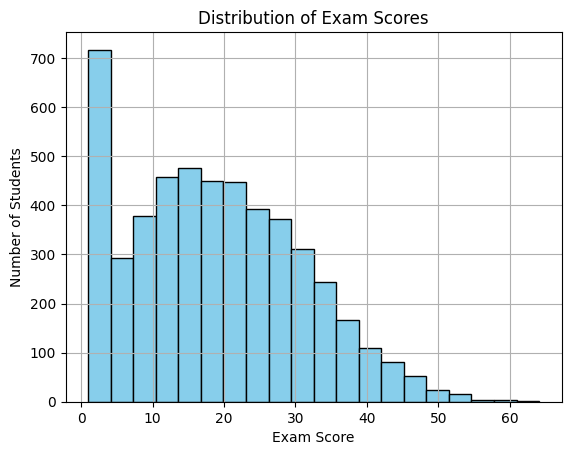

In [10]:
# Histogram

plt.Figure(figsize = (10,6))
plt.hist(data["exam_score"],bins=20,color='skyblue',edgecolor='black')
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()

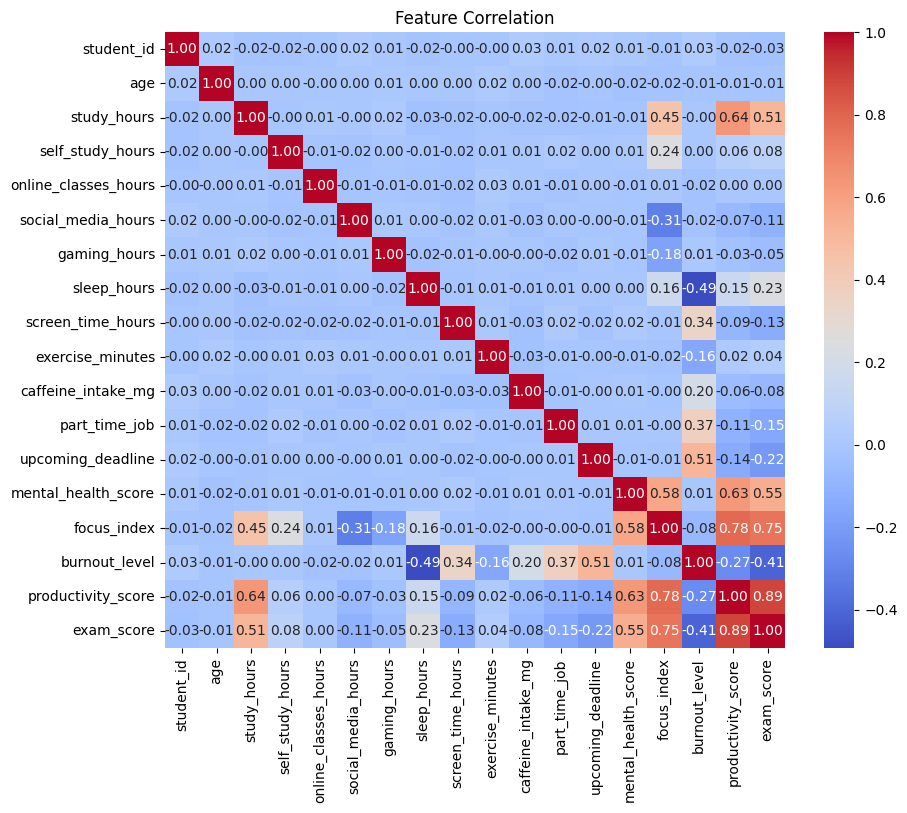

In [11]:
import seaborn as sns
numeric_data = data.select_dtypes(include='number')

plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Feature Correlation')
plt.show()

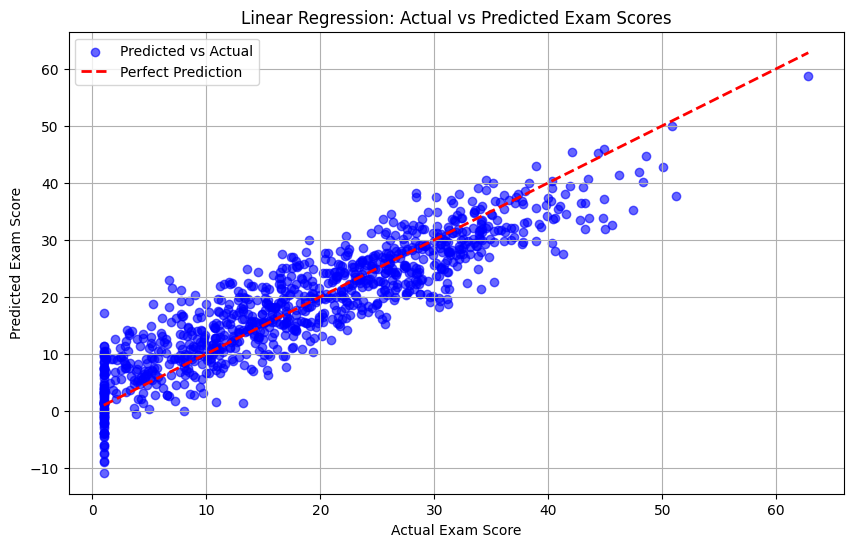

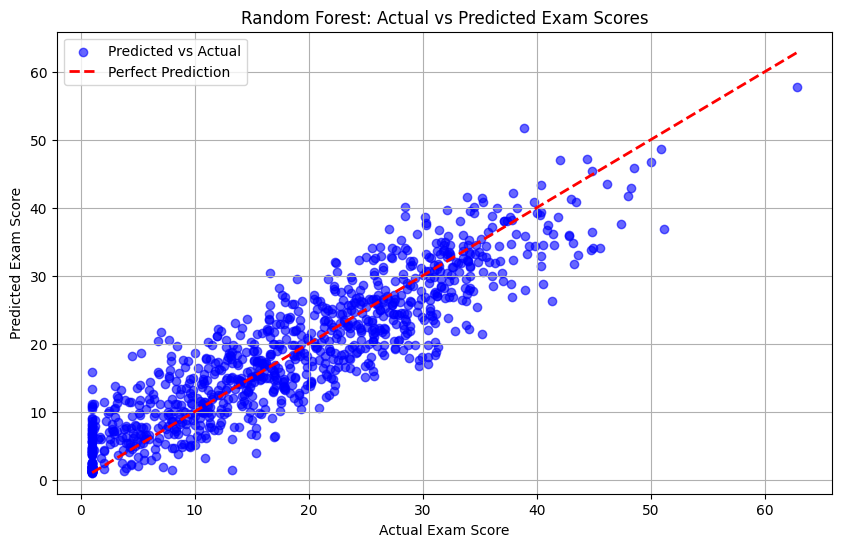

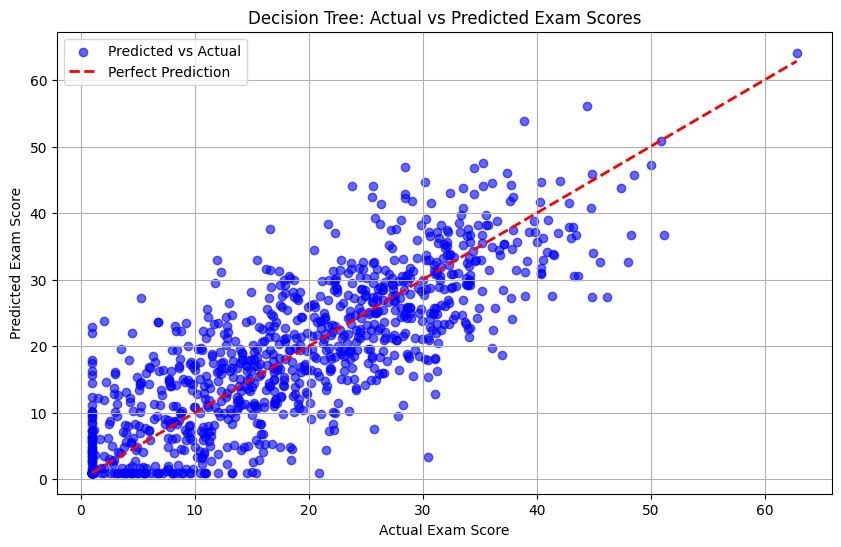

In [12]:

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred1, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression: Actual vs Predicted Exam Scores")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred2, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Random Forest: Actual vs Predicted Exam Scores")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred3, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Decision Tree: Actual vs Predicted Exam Scores")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
new_students = pd.DataFrame([
    {
        'study_hours': 9,
        'self_study_hours': 2,
        'sleep_hours': 7,
        'focus_index': 0.85,
        'burnout_level': 0.2,
        'productivity_score': 80,
        'mental_health_score': 70,
        'screen_time_hours': 4,
        'social_media_hours': 2,
        'gaming_hours': 1
    },
    {
        'study_hours': 6,
        'self_study_hours': 1,
        'sleep_hours': 6,
        'focus_index': 0.65,
        'burnout_level': 0.5,
        'productivity_score': 70,
        'mental_health_score': 60,
        'screen_time_hours': 5,
        'social_media_hours': 3,
        'gaming_hours': 2
    }
])

predicted_new_scores = model1.predict(new_students)
for i, score in enumerate(predicted_new_scores):
    print(f"Predicted exam score for student {i+1}: {score:.2f}")

Predicted exam score for student 1: 44.47
Predicted exam score for student 2: 39.15
